# "Exploratory Data Analysis" 
## para los datos en la carpeta data/processed

In [137]:
from proyecto_ciencia_de_datos.config import PROCESSED_DATA_DIR
import pandas as pd

axa_df = pd.read_csv(PROCESSED_DATA_DIR / 'axa_tidy.csv', sep=',', header='infer')
inegi_df = pd.read_csv(PROCESSED_DATA_DIR / 'inegi_tidy.csv', sep=',', header='infer')
weather_df = pd.read_csv(PROCESSED_DATA_DIR / 'weather_tidy.csv', sep=',', header='infer')

C:\Users\MasterHDXD\AppData\Local\Temp\ipykernel_9932\3754350614.py:4: DtypeWarning: Columns (3,6) have mixed types. Specify dtype option on import or set low_memory=False.
  axa_df = pd.read_csv(PROCESSED_DATA_DIR / 'axa_tidy.csv', sep=',', header='infer')


### Primero una revision rapida de estadisticas

#### axa

In [138]:
axa_df["ESTADO"] = (
    axa_df["ESTADO"]
    .astype(str)
    .str.strip()
    .str.lower()
)
axa_df = axa_df[axa_df['ESTADO'] == 'sonora']
axa_df.head()

,SINIESTRO,LATITUD,LONGITUD,CODIGO POSTAL,CALLE,COLONIA,CAUSA SINIESTRO,TIPO VEHICULO,COLOR,MODELO,...,VOLCADURA,PERDIDA TOTAL,CONDUCTOR DISTRAIDO,FUGA,ALCOHOL,MOTOCICLETA,BICICLETA,SEGURO,TAXI,ANIMAL
2562,6184362.0,27.074450,-109.450288,85870,Calle Jesús Salido Sur,JUAREZ,COLISION Y/O VUELCO,Auto,GRIS,2008.0,...,False,False,False,False,False,False,False,False,False,False
2563,6184810.0,27.958639,-111.040313,85506,Boulevard Manlio Fabio Beltrones,SAN CARLOS,COLISION Y/O VUELCO,Auto,BLANCO,2018.0,...,False,False,False,False,False,False,False,False,False,False
2564,6184934.0,27.958639,-111.040313,85506,Boulevard Manlio Fabio Beltrones,san carlos sonora,COLISION Y/O VUELCO,Auto,NEGRO,2017.0,...,False,False,False,False,False,False,False,False,False,False
2565,6185022.0,27.935550,-110.870271,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,...,False,False,False,False,False,False,False,False,False,False
2566,6185022.0,27.935550,-110.870271,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,...,False,False,False,False,False,False,False,False,False,False


In [139]:
axa_df.info()
print("----------------------------")
axa_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 3709 entries, 2562 to 101190
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SINIESTRO            3709 non-null   float64
 1   LATITUD              3709 non-null   float64
 2   LONGITUD             3709 non-null   float64
 3   CODIGO POSTAL        3620 non-null   object 
 4   CALLE                3581 non-null   object 
 5   COLONIA              3360 non-null   object 
 6   CAUSA SINIESTRO      1808 non-null   object 
 7   TIPO VEHICULO        3706 non-null   object 
 8   COLOR                3696 non-null   object 
 9   MODELO               3706 non-null   float64
 10  NIVEL DAÑO VEHICULO  3587 non-null   object 
 11  PUNTO DE IMPACTO     871 non-null    object 
 12  AÑO                  3709 non-null   int64  
 13  MES                  3709 non-null   object 
 14  DÍA NUMERO           1808 non-null   float64
 15  DIA                  3709 non-null   o

SINIESTRO                 0
LATITUD                   0
LONGITUD                  0
CODIGO POSTAL            89
CALLE                   128
COLONIA                 349
CAUSA SINIESTRO        1901
TIPO VEHICULO             3
COLOR                    13
MODELO                    3
NIVEL DAÑO VEHICULO     122
PUNTO DE IMPACTO       2838
AÑO                       0
MES                       0
DÍA NUMERO             1901
DIA                       0
HORA                      0
ESTADO                    0
CIUDAD                    0
LESIONADOS                0
RELACION LESIONADOS    2860
EDAD LESIONADO         2146
GENERO LESIONADO       2861
NIVEL LESIONADO         930
HOSPITALIZADO             0
FALLECIDO                 0
AMBULANCIA                0
ARBOL                     0
PIEDRA                    0
DORMIDO                   0
GRUA                      0
OBRA CIVIL                0
PAVIMENTO MOJADO          0
EXPLOSION LLANTA          0
VOLCADURA                 0
PERDIDA TOTAL       

In [140]:
axa_df[['MES', 'ESTADO', 'CIUDAD']] = axa_df[['MES', 'ESTADO', 'CIUDAD']].astype('category')


Muchos de los datos de AXA estan como FALSE y esto estaria bien si no fuera por el hecho de que algunas columnas son en su mayoria FALSE, asi que en estas tambien seria importante revisarlas

#### Inegi

In [ ]:
# Solo Sonora
inegi_df = inegi_df[inegi_df['ID_ENTIDAD'] == 26]
inegi_df.head()

,COBERTURA,ID_ENTIDAD,ID_MUNICIPIO,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,...,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS,AÑO,is_outlier
322981,Municipal,26,1,2018,1,0,0,0,Certificado cero,Sin accidente en esta zona,...,0,0,0,0,0,0,Certificado cero,Cifras Definitivas,2018,False
322982,Municipal,26,2,2018,1,2,51,1,Lunes,Accidente en intersección,...,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,2018,False
322983,Municipal,26,2,2018,1,10,0,1,Lunes,Accidente en intersección,...,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,2018,False
322984,Municipal,26,2,2018,1,18,2,2,Martes,Accidente en intersección,...,0,0,0,0,0,0,No fatal,Cifras Definitivas,2018,False
322985,Municipal,26,2,2018,1,19,22,2,Martes,Accidente en intersección,...,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,2018,False


In [162]:
inegi_df.info()
print("----------------------------")
inegi_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 145834 entries, 322981 to 2568588
Data columns (total 47 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   COBERTURA     145834 non-null  object
 1   ID_ENTIDAD    145834 non-null  int64 
 2   ID_MUNICIPIO  145834 non-null  int64 
 3   ANIO          145834 non-null  int64 
 4   MES           145834 non-null  int64 
 5   ID_HORA       145834 non-null  int64 
 6   ID_MINUTO     145834 non-null  int64 
 7   ID_DIA        145834 non-null  int64 
 8   DIASEMANA     145834 non-null  object
 9   URBANA        145834 non-null  object
 10  SUBURBANA     145834 non-null  object
 11  TIPACCID      145834 non-null  object
 12  AUTOMOVIL     145834 non-null  int64 
 13  CAMPASAJ      145834 non-null  int64 
 14  MICROBUS      145834 non-null  int64 
 15  PASCAMION     145834 non-null  int64 
 16  OMNIBUS       145834 non-null  int64 
 17  TRANVIA       145834 non-null  int64 
 18  CAMIONETA     145834 no

COBERTURA       0
ID_ENTIDAD      0
ID_MUNICIPIO    0
ANIO            0
MES             0
ID_HORA         0
ID_MINUTO       0
ID_DIA          0
DIASEMANA       0
URBANA          0
SUBURBANA       0
TIPACCID        0
AUTOMOVIL       0
CAMPASAJ        0
MICROBUS        0
PASCAMION       0
OMNIBUS         0
TRANVIA         0
CAMIONETA       0
CAMION          0
TRACTOR         0
FERROCARRI      0
MOTOCICLET      0
BICICLETA       0
OTROVEHIC       0
CAUSAACCI       0
CAPAROD         0
SEXO            0
ALIENTO         0
CINTURON        0
ID_EDAD         0
CONDMUERTO      0
CONDHERIDO      0
PASAMUERTO      0
PASAHERIDO      0
PEATMUERTO      0
PEATHERIDO      0
CICLMUERTO      0
CICLHERIDO      0
OTROMUERTO      0
OTROHERIDO      0
NEMUERTO        0
NEHERIDO        0
CLASACC         0
ESTATUS         0
AÑO             0
is_outlier      0
dtype: int64

#### Weather

In [143]:
weather_df.head()

,FECHA_HORA,TEMPERATURA_C,LLUVIA_MM,ALTA_LLUVIA_MM,VISIBILIDAD_M,FECHA,AÑO,MES,DIA,HORA
0,2025-11-07 00:00:00,23.0,0.0,0.0,58700.0,2025-11-07,2025,11,7,0
1,2025-11-07 01:00:00,22.2,0.0,0.0,56500.0,2025-11-07,2025,11,7,1
2,2025-11-07 02:00:00,21.2,0.0,0.0,52000.0,2025-11-07,2025,11,7,2
3,2025-11-07 03:00:00,20.4,0.0,0.0,53900.0,2025-11-07,2025,11,7,3
4,2025-11-07 04:00:00,19.7,0.0,0.0,54500.0,2025-11-07,2025,11,7,4


In [144]:
weather_df.info()
print("----------------------------")
weather_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FECHA_HORA      168 non-null    object 
 1   TEMPERATURA_C   168 non-null    float64
 2   LLUVIA_MM       168 non-null    float64
 3   ALTA_LLUVIA_MM  168 non-null    float64
 4   VISIBILIDAD_M   168 non-null    float64
 5   FECHA           168 non-null    object 
 6   AÑO             168 non-null    int64  
 7   MES             168 non-null    int64  
 8   DIA             168 non-null    int64  
 9   HORA            168 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 13.3+ KB
----------------------------


FECHA_HORA        0
TEMPERATURA_C     0
LLUVIA_MM         0
ALTA_LLUVIA_MM    0
VISIBILIDAD_M     0
FECHA             0
AÑO               0
MES               0
DIA               0
HORA              0
dtype: int64

### Exploracion de Vacios (Solo AXA tiene)
Ver que opciones podrian ser utiles antes de elegir solo dropear las columnas vacias

In [145]:
cols_con_vacios = axa_df.columns[axa_df.isnull().any()]
df_vacios_axa = axa_df[cols_con_vacios]
df_vacios_axa.head(10)

# Tener en cuenta que el total de datos es: 108670 

,CODIGO POSTAL,CALLE,COLONIA,CAUSA SINIESTRO,TIPO VEHICULO,COLOR,MODELO,NIVEL DAÑO VEHICULO,PUNTO DE IMPACTO,DÍA NUMERO,RELACION LESIONADOS,EDAD LESIONADO,GENERO LESIONADO,NIVEL LESIONADO
2562,85870,Calle Jesús Salido Sur,JUAREZ,COLISION Y/O VUELCO,Auto,GRIS,2008.0,Sin daño,Costado der delantero,1.0,NaN,0.0,NaN,NaN
2563,85506,Boulevard Manlio Fabio Beltrones,SAN CARLOS,COLISION Y/O VUELCO,Auto,BLANCO,2018.0,Bajo,Costado der central,1.0,NaN,0.0,NaN,NaN
2564,85506,Boulevard Manlio Fabio Beltrones,san carlos sonora,COLISION Y/O VUELCO,Auto,NEGRO,2017.0,Bajo,Costado izq delantero,1.0,NaN,0.0,NaN,NaN
2565,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,Bajo,Costado izq central,1.0,Tercero Pasajero,31.0,M,NaN
2566,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,Bajo,Costado izq central,1.0,Tercero Conductor,31.0,M,NaN
2567,85000,Rodolfo Elías Calles,Ciudad Obregón Centro (Fundo Legal),COLISION Y/O VUELCO,Auto,AZUL,2018.0,Bajo,Trasero,1.0,NaN,0.0,NaN,NaN
2568,85864,Carretera Navojoa - Huatabampo,NaN,COLISION Y/O VUELCO,Auto,GUINDA,2004.0,Bajo,Costado der delantero,1.0,Conductor Asegurado,20.0,M,NaN
2569,85040,París,col bellavista,COLISION Y/O VUELCO,Auto,GRIS,2016.0,Bajo,Costado der delantero,1.0,NaN,0.0,NaN,NaN
2570,85800,Treceava,Estadio Viejo,ATROPELLO,Auto,BLANCO,2018.0,Sin daño,Costado izq central,1.0,NaN,0.0,NaN,NaN
2571,0,AJUSTE EN LINEA AMBERES 557,AJUSTE EN LINEA NAINARY DEL YAKI,COLISION Y/O VUELCO,Auto,BLANCO,0.0,NaN,NaN,2.0,NaN,0.0,NaN,NaN


In [146]:
df_vacios_axa.isna().sum()

CODIGO POSTAL            89
CALLE                   128
COLONIA                 349
CAUSA SINIESTRO        1901
TIPO VEHICULO             3
COLOR                    13
MODELO                    3
NIVEL DAÑO VEHICULO     122
PUNTO DE IMPACTO       2838
DÍA NUMERO             1901
RELACION LESIONADOS    2860
EDAD LESIONADO         2146
GENERO LESIONADO       2861
NIVEL LESIONADO         930
dtype: int64

Algunas de estas columnas tiene muy pocos vacios y otras no nos son necesarias para lo que estamos buscando explicar. 
No son necesarias para lo que buscamos: 
Genero Lesionado, Punto de Impacto, Color, Codigo Postal, Calle, Colonia, Dia Numero, Relacion Lesionados, Nivel Lesionado, Nivel Daño Vehiculo, Edad Lesionado

Son necesarias y aplicaremos alguna tecnica para llenarlas: 
Causa Siniestro, Tipo Vehiculo, Modelo

In [147]:
axa_df = axa_df.drop(columns=['EDAD LESIONADO', 'PUNTO DE IMPACTO', 'GENERO LESIONADO', 'COLOR', 'CODIGO POSTAL', 'CALLE', 'COLONIA', 'DÍA NUMERO', 'RELACION LESIONADOS', 'NIVEL LESIONADO', 'NIVEL DAÑO VEHICULO'])

In [148]:
axa_df.head()

,SINIESTRO,LATITUD,LONGITUD,CAUSA SINIESTRO,TIPO VEHICULO,MODELO,AÑO,MES,DIA,HORA,...,VOLCADURA,PERDIDA TOTAL,CONDUCTOR DISTRAIDO,FUGA,ALCOHOL,MOTOCICLETA,BICICLETA,SEGURO,TAXI,ANIMAL
2562,6184362.0,27.074450,-109.450288,COLISION Y/O VUELCO,Auto,2008.0,2021,ABRIL,JUEVES,12,...,False,False,False,False,False,False,False,False,False,False
2563,6184810.0,27.958639,-111.040313,COLISION Y/O VUELCO,Auto,2018.0,2021,ABRIL,JUEVES,14,...,False,False,False,False,False,False,False,False,False,False
2564,6184934.0,27.958639,-111.040313,COLISION Y/O VUELCO,Auto,2017.0,2021,ABRIL,JUEVES,14,...,False,False,False,False,False,False,False,False,False,False
2565,6185022.0,27.935550,-110.870271,COLISION Y/O VUELCO,Camión,2014.0,2021,ABRIL,JUEVES,15,...,False,False,False,False,False,False,False,False,False,False
2566,6185022.0,27.935550,-110.870271,COLISION Y/O VUELCO,Camión,2014.0,2021,ABRIL,JUEVES,15,...,False,False,False,False,False,False,False,False,False,False


- Los siniestros nos importan por que nos dan informacion sobre el choque y puede que indique la causa del choque pero muchos datos son faltantes, asi que los vamos a sustituir por "Sin dato"

- Tipo Vehiculo y Modelo los vamos a llenar con el promedio



In [149]:
axa_df['CAUSA SINIESTRO'] = axa_df['CAUSA SINIESTRO'].fillna('Sin dato')
axa_df['TIPO VEHICULO'] = axa_df['TIPO VEHICULO'].fillna(axa_df['TIPO VEHICULO'].mode()[0])
axa_df['MODELO'] = axa_df['MODELO'].fillna(axa_df['MODELO'].mode()[0])
axa_df[['CAUSA SINIESTRO', 'TIPO VEHICULO']] = axa_df[['CAUSA SINIESTRO', 'TIPO VEHICULO']].astype('category')


In [150]:
print(axa_df.isna().sum())

SINIESTRO              0
LATITUD                0
LONGITUD               0
CAUSA SINIESTRO        0
TIPO VEHICULO          0
MODELO                 0
AÑO                    0
MES                    0
DIA                    0
HORA                   0
ESTADO                 0
CIUDAD                 0
LESIONADOS             0
HOSPITALIZADO          0
FALLECIDO              0
AMBULANCIA             0
ARBOL                  0
PIEDRA                 0
DORMIDO                0
GRUA                   0
OBRA CIVIL             0
PAVIMENTO MOJADO       0
EXPLOSION LLANTA       0
VOLCADURA              0
PERDIDA TOTAL          0
CONDUCTOR DISTRAIDO    0
FUGA                   0
ALCOHOL                0
MOTOCICLETA            0
BICICLETA              0
SEGURO                 0
TAXI                   0
ANIMAL                 0
dtype: int64


## Analisis de Anomalias (Outliers)

### AXA

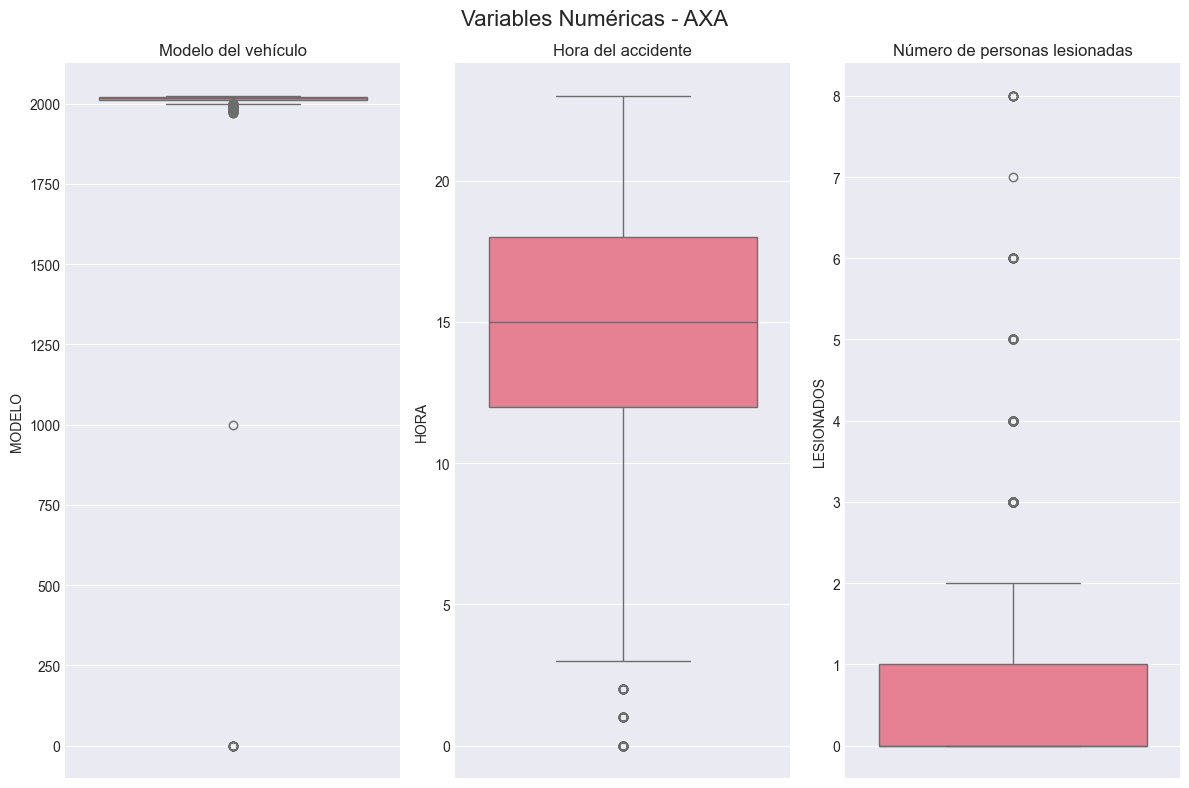

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 8))
fig.suptitle('Variables Numéricas - AXA', fontsize=16)

# Aplanar el array 2D a 1D
axes = axes.flatten()

# indexar con [0], [1], [2], [3]
sns.boxplot(data=axa_df, y='MODELO', ax=axes[0])
axes[0].set_title('Modelo del vehículo')

sns.boxplot(data=axa_df, y='HORA', ax=axes[1])
axes[1].set_title('Hora del accidente')

sns.boxplot(data=axa_df, y='LESIONADOS', ax=axes[2])
axes[2].set_title('Número de personas lesionadas')



plt.tight_layout()
plt.show()

Aunque existen outliers en la hora del accidente y en el numero de personas lesionadas, estas se encuentran dentro de los valores que se podrian esperar de accidentes, pero en los modelos de vehiculos parece haber valores raros, habra que visualizar esto.

In [152]:
print("Mayores que 2024: ", axa_df[axa_df['MODELO'] > 2024]['MODELO'].value_counts())
print("Menores que 1950: ", axa_df[axa_df['MODELO'] < 1950]['MODELO'].value_counts())

Mayores que 2024:  Series([], Name: count, dtype: int64)
Menores que 1950:  MODELO
0.0       16
1000.0     1
Name: count, dtype: int64


El primer vehiculo de la historia se fue creado alrededor de 1900, por lo tanto estos valores no encajan con el resto, sin embargo, los modelos de vehiculos deberian ser categoricos, asi que vamos a convertir esta columna a categorico y transformar el 0.0 y 1000.0 en 'Sin Dato'

In [ ]:
# Convertir outlier a 'Sin Dato'
axa_df['MODELO'] = axa_df['MODELO'].apply(lambda x: 'Sin Dato' if x < 1900 or x > 2024 else str(int(x)))


In [154]:
axa_df['MODELO'].value_counts()

MODELO
2017        407
2018        365
2019        326
2016        307
2020        284
2015        224
2012        166
2013        163
2014        161
2021        124
2007        100
2011        100
2022         99
2006         92
2008         92
2023         88
2010         85
2005         83
2009         66
2003         50
2024         45
2004         40
2002         32
2000         30
2001         24
1998         20
1999         18
Sin Dato     17
1995         15
1997         13
1990          9
1996          7
1992          6
1991          5
1986          5
1994          5
1981          4
1993          4
1985          3
1970          3
1984          3
1987          3
1988          3
1978          2
1976          2
1974          2
1977          2
1975          2
1989          1
1983          1
1982          1
Name: count, dtype: int64

### INEGI

In [ ]:
"""
Análisis de Outliers Específico para Dataset INEGI
Basado en el diccionario de datos oficial
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================================
# VALIDACIÓN DE RANGOS PERMITIDOS (Detectar Errores de Captura)
# ============================================================================

def validar_rangos_inegi(df):
    """
    Valida que los valores estén dentro de rangos permitidos según el diccionario
    """
    print("=" * 80)
    print("VALIDACIÓN DE RANGOS PERMITIDOS")
    print("=" * 80)
    
    validaciones = {
        'ID_HORA': {'min': 0, 'max': 23, 'especial': [99], 'descripcion': 'Hora (99=no especificado)'},
        'ID_MINUTO': {'min': 0, 'max': 59, 'especial': [99], 'descripcion': 'Minutos (99=no especificado)'},
        'ID_DIA': {'min': 1, 'max': 31, 'especial': [32], 'descripcion': 'Día (32=no especificado)'},
        'ID_EDAD': {'min': 0, 'max': 99, 'especial': [0, 99], 'descripcion': 'Edad (0=fugado, 99=se ignora)'},
        'MES': {'min': 1, 'max': 12, 'especial': [], 'descripcion': 'Mes'},
        'ANIO': {'min': 1997, 'max': 2024, 'especial': [], 'descripcion': 'Año'}
    }
    
    resultados = []
    
    for columna, reglas in validaciones.items():
        if columna in df.columns:
            # Convertir a numérico si es necesario
            valores = pd.to_numeric(df[columna], errors='coerce')
            
            # Detectar valores fuera de rango (excluyendo valores especiales)
            fuera_rango = valores[
                ~valores.isin(reglas['especial']) & 
                ((valores < reglas['min']) | (valores > reglas['max']))
            ]
            
            n_fuera = len(fuera_rango)
            pct_fuera = (n_fuera / len(df)) * 100
            
            resultados.append({
                'Variable': columna,
                'Descripción': reglas['descripcion'],
                'Rango_Válido': f"{reglas['min']}-{reglas['max']}",
                'Valores_Especiales': str(reglas['especial']),
                'Fuera_Rango': n_fuera,
                'Porcentaje': f"{pct_fuera:.3f}%"
            })
            
            if n_fuera > 0:
                print(f"\n⚠️  {columna}: {n_fuera} valores fuera de rango ({pct_fuera:.3f}%)")
                print(f"    Valores únicos fuera de rango: {fuera_rango.unique()[:10]}")
    
    return pd.DataFrame(resultados)


# Ejemplo de uso (descomenta cuando tengas el dataframe cargado):
# analisis_completo_inegi(inegi_df)

# O ejecuta análisis individuales:
df_validacion = validar_rangos_inegi(inegi_df)
print("\nResumen de validación de rangos:")
print(df_validacion.to_string(index=False))
# carambolas = analizar_vehiculos_involucrados(inegi_df)
# catastroficos = analizar_victimas(inegi_df)
# analizar_patrones_temporales(inegi_df)

1. VALIDACIÓN DE RANGOS PERMITIDOS

⚠️  ID_DIA: 431 valores fuera de rango (0.296%)
    Valores únicos fuera de rango: [0]

Resumen de validación de rangos:
 Variable                   Descripción Rango_Válido Valores_Especiales  Fuera_Rango Porcentaje
  ID_HORA     Hora (99=no especificado)         0-23               [99]            0     0.000%
ID_MINUTO  Minutos (99=no especificado)         0-59               [99]            0     0.000%
   ID_DIA      Día (32=no especificado)         1-31               [32]          431     0.296%
  ID_EDAD Edad (0=fugado, 99=se ignora)         0-99            [0, 99]            0     0.000%
      MES                           Mes         1-12                 []            0     0.000%
     ANIO                           Año    1997-2024                 []            0     0.000%


In [193]:
inegi_df['ID_DIA'].describe()

count    145834.000000
mean         15.855109
std           8.920287
min           1.000000
25%           8.000000
50%          16.000000
75%          24.000000
max          32.000000
Name: ID_DIA, dtype: float64

Segun el diccionario de datos, no deberia haber dias con el valor 0, por lo tanto estos los vamos a convertir a 32, el cual es el valor especificado para dias no especificados

In [192]:
inegi_df['ID_DIA'].replace(0, 32)

322981     32
322982      1
322983      1
322984      2
322985      2
           ..
2568584    26
2568585    28
2568586    30
2568587    30
2568588     2
Name: ID_DIA, Length: 145834, dtype: int64

### Weather

In [213]:
"""
Local Outlier Factor (LOF) con visualización de anomaly scores
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ============================================================================
# LOF - DETECCIÓN
# ============================================================================

def detectar_outliers_lof(df, columnas, n_neighbors=20, contamination=0.05):
    """
    Detecta outliers usando Local Outlier Factor
    
    Parámetros:
    -----------
    df : DataFrame
    columnas : list - columnas numéricas a analizar
    n_neighbors : int - número de vecinos (mayor = más global, menor = más local)
    contamination : float - proporción esperada de outliers (0.05 = 5%)
    
    Retorna:
    --------
    DataFrame con columnas 'outlier_LOF' y 'lof_score'
    """
    # Preparar datos
    X = df[columnas].values
    
    # Entrenar LOF
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        novelty=False
    )
    
    # Predecir (-1 = outlier, 1 = normal)
    predicciones = lof.fit_predict(X)
    
    # Obtener scores (más negativo = más anómalo)
    scores = lof.negative_outlier_factor_
    
    # Agregar al dataframe
    df_resultado = df.copy()
    df_resultado['outlier_LOF'] = predicciones
    df_resultado['lof_score'] = scores
    
    # Score normalizado (más intuitivo: valores altos = más anómalo)
    # LOF score de 1 = normal, >1 = outlier
    df_resultado['lof_factor'] = -scores  # Invertir para que sea más intuitivo
    
    return df_resultado, lof

# ============================================================================
# VISUALIZACIÓN PRINCIPAL: LOF SCORES + PCA
# ============================================================================

def visualizar_lof_scores(df_lof, columnas):
    """
    Visualización principal: muestra LOF scores y proyección PCA
    Esta es la visualización MÁS IMPORTANTE para entender LOF
    """
    # Normalizar para PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_lof[columnas])
    
    # PCA para visualización 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Crear figura con 3 subplots
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # ===== PLOT 1: PCA con colores por LOF score =====
    ax1 = fig.add_subplot(gs[:, 0])
    
    scatter = ax1.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=df_lof['lof_factor'],
        cmap='RdYlBu_r',  # Rojo = outlier, Azul = normal
        s=100,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )
    
    # Resaltar outliers extremos
    mask_outliers = df_lof['outlier_LOF'] == -1
    ax1.scatter(
        X_pca[mask_outliers, 0],
        X_pca[mask_outliers, 1],
        s=300,
        facecolors='none',
        edgecolors='red',
        linewidth=2,
        label=f'Outliers ({mask_outliers.sum()})'
    )
    
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax1.set_title('LOF Scores en Proyección PCA\n(Colores: Rojo=Anómalo, Azul=Normal)')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('LOF Factor (mayor = más anómalo)', rotation=270, labelpad=20)
    
    # ===== PLOT 2: Distribución de LOF scores =====
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Histograma separado por tipo
    ax2.hist(
        df_lof[df_lof['outlier_LOF'] == 1]['lof_factor'],
        bins=30,
        alpha=0.6,
        label='Normal',
        color='blue',
        edgecolor='black'
    )
    ax2.hist(
        df_lof[df_lof['outlier_LOF'] == -1]['lof_factor'],
        bins=30,
        alpha=0.6,
        label='Outliers',
        color='red',
        edgecolor='black'
    )
    
    ax2.axvline(
        x=1.0,
        color='green',
        linestyle='--',
        linewidth=2,
        label='Umbral (LOF=1)'
    )
    
    ax2.set_xlabel('LOF Factor')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de LOF Scores')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # ===== PLOT 3: Top outliers ordenados =====
    ax3 = fig.add_subplot(gs[1, 1])
    
    # Ordenar por LOF score
    df_sorted = df_lof.sort_values('lof_factor', ascending=False).reset_index(drop=True)
    top_n = min(30, len(df_sorted))
    
    colors = ['red' if x == -1 else 'blue' for x in df_sorted['outlier_LOF'].head(top_n)]
    
    ax3.barh(
        range(top_n),
        df_sorted['lof_factor'].head(top_n),
        color=colors,
        alpha=0.6,
        edgecolor='black'
    )
    ax3.axvline(x=1.0, color='green', linestyle='--', linewidth=2, label='Umbral')
    ax3.set_xlabel('LOF Factor')
    ax3.set_ylabel('Índice (ordenado)')
    ax3.set_title(f'Top {top_n} observaciones más anómalas')
    ax3.legend()
    ax3.grid(axis='x', alpha=0.3)
    ax3.invert_yaxis()
    
    # ===== PLOT 4: Boxplot por variable =====
    ax4 = fig.add_subplot(gs[0, 2])
    
    df_viz = df_lof.copy()
    df_viz['Tipo'] = df_viz['outlier_LOF'].apply(lambda x: 'Outlier' if x == -1 else 'Normal')
    
    # Seleccionar variable más relevante (la que más varía)
    var_principal = columnas[0]  # Por defecto la primera
    
    sns.boxplot(
        data=df_viz,
        x='Tipo',
        y=var_principal,
        ax=ax4,
        palette={'Normal': 'lightblue', 'Outlier': 'salmon'}
    )
    ax4.set_title(f'Comparación: {var_principal}')
    ax4.grid(axis='y', alpha=0.3)
    
    # ===== PLOT 5: Tabla de estadísticas =====
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')
    
    # Calcular estadísticas
    n_total = len(df_lof)
    n_outliers = (df_lof['outlier_LOF'] == -1).sum()
    pct_outliers = (n_outliers / n_total) * 100
    lof_max = df_lof['lof_factor'].max()
    lof_mean = df_lof['lof_factor'].mean()
    
    stats_text = f"""
    ESTADÍSTICAS LOF
    {'='*30}
    
    Total observaciones: {n_total}
    Outliers detectados: {n_outliers}
    Porcentaje: {pct_outliers:.2f}%
    
    LOF Factor máximo: {lof_max:.2f}
    LOF Factor promedio: {lof_mean:.2f}
    
    Umbral usado: 1.0
    N° vecinos: {df_lof.attrs.get('n_neighbors', 'N/A')}
    Contamination: {df_lof.attrs.get('contamination', 'N/A')}
    """
    
    ax5.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle('Análisis LOF (Local Outlier Factor)', fontsize=16, y=0.98)
    plt.show()

# ============================================================================
# VISUALIZACIÓN 2: ANÁLISIS POR VARIABLE
# ============================================================================

def visualizar_lof_por_variable(df_lof, columnas):
    """
    Muestra cómo cada variable contribuye a los outliers
    """
    n_cols = len(columnas)
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    
    if n_cols == 1:
        axes = [axes]
    
    for idx, col in enumerate(columnas):
        # Scatter plot: variable vs LOF score
        axes[idx].scatter(
            df_lof[df_lof['outlier_LOF'] == 1][col],
            df_lof[df_lof['outlier_LOF'] == 1]['lof_factor'],
            c='blue', alpha=0.5, s=50, label='Normal'
        )
        axes[idx].scatter(
            df_lof[df_lof['outlier_LOF'] == -1][col],
            df_lof[df_lof['outlier_LOF'] == -1]['lof_factor'],
            c='red', alpha=0.8, s=100, marker='X', label='Outlier'
        )
        
        axes[idx].axhline(y=1.0, color='green', linestyle='--', linewidth=2, alpha=0.7)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('LOF Factor')
        axes[idx].set_title(f'{col} vs LOF Score')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# RESUMEN ESTADÍSTICO
# ============================================================================

def resumen_lof(df_lof, columnas):
    """
    Genera reporte estadístico de outliers detectados por LOF
    """
    mask_outliers = df_lof['outlier_LOF'] == -1
    outliers = df_lof[mask_outliers]
    normales = df_lof[~mask_outliers]
    
    print("=" * 80)
    print("RESUMEN LOF (LOCAL OUTLIER FACTOR)")
    print("=" * 80)
    
    print(f"\n📊 Información General:")
    print(f"   - Total observaciones: {len(df_lof)}")
    print(f"   - Outliers detectados: {len(outliers)} ({len(outliers)/len(df_lof)*100:.2f}%)")
    print(f"   - Normales: {len(normales)} ({len(normales)/len(df_lof)*100:.2f}%)")
    
    print(f"\n📈 LOF Scores:")
    print(f"   - LOF Factor promedio (todos): {df_lof['lof_factor'].mean():.3f}")
    print(f"   - LOF Factor máximo: {df_lof['lof_factor'].max():.3f}")
    print(f"   - LOF Factor mínimo: {df_lof['lof_factor'].min():.3f}")
    print(f"   - LOF Factor promedio (outliers): {outliers['lof_factor'].mean():.3f}")
    
    print(f"\n🔍 Top 10 outliers más extremos:")
    top_outliers = df_lof.nlargest(10, 'lof_factor')
    print(top_outliers[columnas + ['lof_factor']].to_string(index=False))
    
    print("\n" + "=" * 80)
    
    return outliers

# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def analisis_completo_lof(weather_df, columnas, n_neighbors=20, contamination=0.05):
    """
    Análisis completo con LOF
    """
    print("🔄 Ejecutando LOF...")
    
    # Detectar outliers
    df_lof, modelo = detectar_outliers_lof(
        weather_df, 
        columnas, 
        n_neighbors=n_neighbors,
        contamination=contamination
    )
    
    # Guardar parámetros en el dataframe
    df_lof.attrs['n_neighbors'] = n_neighbors
    df_lof.attrs['contamination'] = contamination
    
    print("✅ LOF completado\n")
    
    # Resumen estadístico
    outliers = resumen_lof(df_lof, columnas)
    
    # Visualizaciones
    # print("\n📊 Generando visualizaciones...\n")
    # visualizar_lof_scores(df_lof, columnas)
    # visualizar_lof_por_variable(df_lof, columnas)
    
    print("\n✅ Análisis completo")
    
    return df_lof, outliers

# ============================================================================
# EJEMPLO DE USO
# ============================================================================
columnas=['TEMPERATURA_C', 'LLUVIA_MM', 'ALTA_LLUVIA_MM', 'VISIBILIDAD_M']
# Uso completo:
df_resultado, outliers = analisis_completo_lof(
    weather_df,
    columnas=['TEMPERATURA_C', 'LLUVIA_MM', 'ALTA_LLUVIA_MM', 'VISIBILIDAD_M'],
    n_neighbors=20,      # Ajustar: más alto = más global, más bajo = más local
    contamination=0.05   # Proporción esperada de outliers (5%)
)
# Ver outliers:
# print(outliers[['FECHA_HORA', 'TEMPERATURA_C', 'LLUVIA_MM', 'lof_factor']])


🔄 Ejecutando LOF...
✅ LOF completado

RESUMEN LOF (LOCAL OUTLIER FACTOR)

📊 Información General:
   - Total observaciones: 168
   - Outliers detectados: 9 (5.36%)
   - Normales: 159 (94.64%)

📈 LOF Scores:
   - LOF Factor promedio (todos): 153.504
   - LOF Factor máximo: 9898.375
   - LOF Factor mínimo: 0.935
   - LOF Factor promedio (outliers): 2846.549

🔍 Top 10 outliers más extremos:
 TEMPERATURA_C  LLUVIA_MM  ALTA_LLUVIA_MM  VISIBILIDAD_M  lof_factor
          20.0        0.0             0.0        33400.0 9898.375498
          20.0        0.0             0.0        33200.0 9761.642401
          21.4        0.0             0.0        34900.0 5948.566520
          34.6        0.0             0.0        24140.0    1.847003
          34.4        0.0             0.0        24140.0    1.727102
          30.0        0.0             0.0        84000.0    1.720210
          30.5        0.0             0.0        83800.0    1.712108
          22.2        0.0             0.0        24140.0  

Aunque con LOF detectamos outliers muy grandes, estos son los registros reales del clima y aunque ahorita son outliers, en realidad es por que estamos entrando al invierno y faltan mas datos.